<a href="https://colab.research.google.com/github/hnsgrn07/Model-Selection-and-Evaluation/blob/main/Phase_3_DataMining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 2: Model Training**

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# 1. Load the Dataset
file_path = 'https://raw.githubusercontent.com/hnsgrn07/Model-Selection-and-Evaluation/refs/heads/main/Phase%202_%20Data%20Preprocessing%20and%20Exploration%20-%20PHASE%203%20DATASET.csv'
df = pd.read_csv(file_path)

# 2. Final Data Cleaning
df = df[df['is_positive'] != '#VALUE!'].copy()
df['is_positive'] = df['is_positive'].astype(int)

# Fill the missing prices with the median price
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce')
df['price_cleaned'] = df['price_cleaned'].fillna(df['price_cleaned'].median())

# Drop
df = df.dropna()

# 3. Define Features (X) and Target (y)
X = df.drop('is_positive', axis=1)
y = df['is_positive']

# 4. Train-Test Split (80/20 Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data: {X_test.shape[0]} rows")

# 5. Train the Baseline Model (Logistic Regression)
print("Training Logistic Regression...")
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)

# 6. Train the Complex Model (Random Forest)
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7. Save Models
joblib.dump(log_reg, 'logistic_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Models are trained and saved as .pkl files.")

Training Data: 8259 rows
Testing Data: 2065 rows
Training Logistic Regression...
Training Random Forest...
Models are trained and saved as .pkl files.


# **Step 3: Model Evaluation**

--- Logistic Regression Evaluation ---
Accuracy:  0.8228
Precision: 0.8282
Recall:    0.9894
F1-Score:  0.9017

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.06      0.10       369
           1       0.83      0.99      0.90      1696

    accuracy                           0.82      2065
   macro avg       0.68      0.52      0.50      2065
weighted avg       0.78      0.82      0.76      2065

------------------------------
--- Random Forest Evaluation ---
Accuracy:  0.8107
Precision: 0.8383
Recall:    0.9534
F1-Score:  0.8921

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.15      0.23       369
           1       0.84      0.95      0.89      1696

    accuracy                           0.81      2065
   macro avg       0.63      0.55      0.56      2065
weighted avg       0.76      0.81      0.77      2065

------------------------------


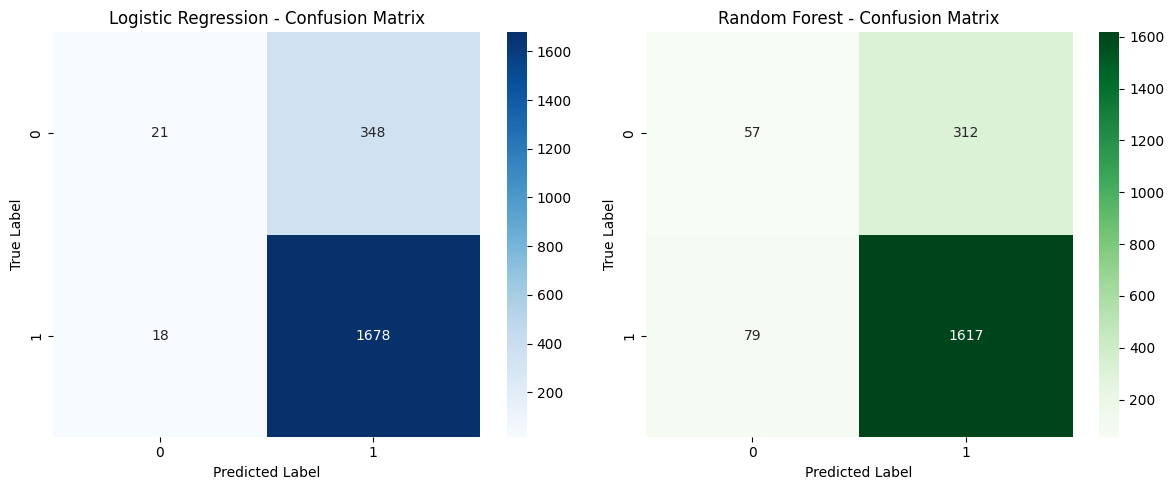

In [9]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Load the models from Step 2
log_reg = joblib.load('logistic_regression_model.pkl')
rf_model = joblib.load('random_forest_model.pkl')

# 2. Make Predictions on the Test Set (X_test from Step 2)
y_pred_log = log_reg.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# 3. Print the evaluation metrics
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} Evaluation ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 30)

# 4. Print scores
evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Random Forest", y_test, y_pred_rf)

# 5. Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# **Step 4: Model Improvement**

Testing different model settings...
Best Settings: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 20, 'class_weight': 'balanced_subsample'}

-------Improved Model Evaluation-------
Accuracy:  0.7709
Precision: 0.8699
Recall:    0.8479
F1-Score:  0.8588

Full Report:
              precision    recall  f1-score   support

           0       0.37      0.42      0.39       369
           1       0.87      0.85      0.86      1696

    accuracy                           0.77      2065
   macro avg       0.62      0.63      0.63      2065
weighted avg       0.78      0.77      0.78      2065



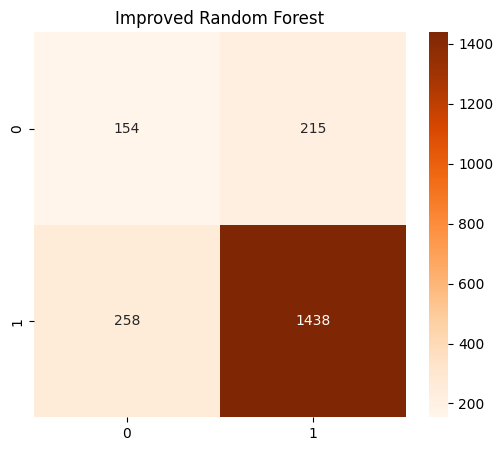

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

#1. Load Data
df = pd.read_csv('https://raw.githubusercontent.com/hnsgrn07/Model-Selection-and-Evaluation/refs/heads/main/Phase%202_%20Data%20Preprocessing%20and%20Exploration%20-%20PHASE%203%20DATASET.csv')
df = df[df['is_positive'] != '#VALUE!'].copy()
df['is_positive'] = df['is_positive'].astype(int)
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce').fillna(df['price_cleaned'].median())
df = df.dropna()

X = df.drop('is_positive', axis=1)
y = df['is_positive']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#2. Set up Hyperparameter Tuning
print("Testing different model settings...")
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

#3. Run Randomized Search
rf_base = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(estimator=rf_base, param_distributions=param_dist,
                                   n_iter=10, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print(f"Best Settings: {random_search.best_params_}")

#4. Evaluate the Improved Model
y_pred_best = best_rf.predict(X_test)
print("\n-------Improved Model Evaluation-------")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best):.4f}")

print("\nFull Report:")
print(classification_report(y_test, y_pred_best))

#5. Save the improved model and matrix
joblib.dump(best_rf, 'improved_random_forest_model.pkl')

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Oranges')
plt.title('Improved Random Forest')
plt.show()

# **Step 5: Model Interpretation**

Top 10 Important Features:
 languagesupp_count            0.177443
dlc_count                     0.096162
cat_SteamCloud                0.065561
price_cleaned                 0.065542
genre_Indie                   0.047647
genre_Adventure               0.040252
cat_ControllerSupport         0.040103
genre_RPG                     0.038663
genre_MassivelyMultiplayer    0.036901
cat_Multiplayer               0.036837
dtype: float64


/tmp/ipykernel_3680/1829111516.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')


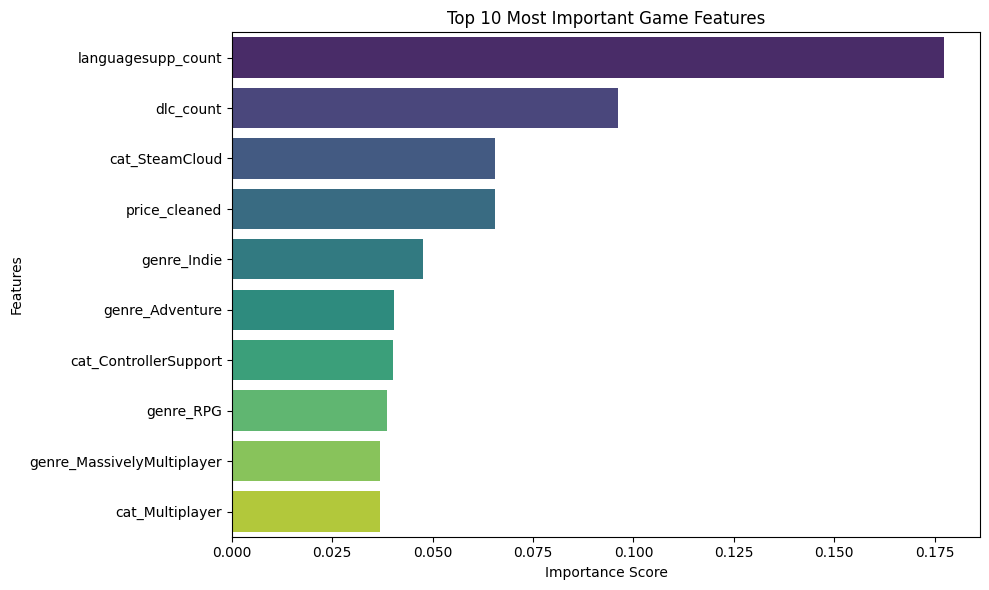

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv('https://raw.githubusercontent.com/hnsgrn07/Model-Selection-and-Evaluation/refs/heads/main/Phase%202_%20Data%20Preprocessing%20and%20Exploration%20-%20PHASE%203%20DATASET.csv')
df = df[df['is_positive'] != '#VALUE!'].copy()
df['is_positive'] = df['is_positive'].astype(int)
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce').fillna(df['price_cleaned'].median())
df = df.dropna()

X = df.drop('is_positive', axis=1)
y = df['is_positive']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Train the Improved Model
best_rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=4,
                                 min_samples_split=2, class_weight='balanced_subsample', random_state=42)
best_rf.fit(X_train, y_train)

# 3. Top 10 Features
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

print("Top 10 Important Features:\n", feat_imp)

# 4. Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_imp.index, palette='viridis')
plt.title('Top 10 Most Important Game Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()

# Save bar chart as png
plt.savefig('feature_importance.png')
plt.show()
